# Grad-CAM Explainability for Soil Image Classification

## Objective

This notebook uses Grad-CAM (Gradient-weighted Class Activation Mapping)
to explain the predictions of the fine-tuned EfficientNetB0 soil
classification model.

Grad-CAM generates a heatmap showing the image regions that contribute
most strongly to the model's predicted soil class.

The analysis is used to:
- visualize model attention,
- identify important soil-image regions,
- check whether the model focuses on relevant soil characteristics,
- inspect potentially incorrect or context-driven predictions.

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Models/efficientnet_soil_classifier_finetuned.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Fine-tuned EfficientNetB0 loaded successfully.")
print("Number of layers:", len(model.layers))

Fine-tuned EfficientNetB0 loaded successfully.
Number of layers: 4


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,177,882 (31.20 MB)

 Trainable params: 2,059,671 (7.86 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

 Optimizer params: 4,119,344 (15.71 MB)

In [ ]:
base_model = model.get_layer("efficientnetb0")

print("EfficientNetB0 layers:", len(base_model.layers))

for i, layer in enumerate(base_model.layers[-20:]):
    print(i - 20 + len(base_model.layers), layer.name, layer.output.shape)

EfficientNetB0 layers: 238
218 block6d_project_conv (None, 7, 7, 192)
219 block6d_project_bn (None, 7, 7, 192)
220 block6d_drop (None, 7, 7, 192)
221 block6d_add (None, 7, 7, 192)
222 block7a_expand_conv (None, 7, 7, 1152)
223 block7a_expand_bn (None, 7, 7, 1152)
224 block7a_expand_activation (None, 7, 7, 1152)
225 block7a_dwconv (None, 7, 7, 1152)
226 block7a_bn (None, 7, 7, 1152)
227 block7a_activation (None, 7, 7, 1152)
228 block7a_se_squeeze (None, 1152)
229 block7a_se_reshape (None, 1, 1, 1152)
230 block7a_se_reduce (None, 1, 1, 48)
231 block7a_se_expand (None, 1, 1, 1152)
232 block7a_se_excite (None, 7, 7, 1152)
233 block7a_project_conv (None, 7, 7, 320)
234 block7a_project_bn (None, 7, 7, 320)
235 top_conv (None, 7, 7, 1280)
236 top_bn (None, 7, 7, 1280)
237 top_activation (None, 7, 7, 1280)


In [ ]:
gradcam_layer_name = "top_activation"

print("Grad-CAM layer:", gradcam_layer_name)
print("Output shape:", base_model.get_layer(gradcam_layer_name).output.shape)

Grad-CAM layer: top_activation
Output shape: (None, 7, 7, 1280)


In [ ]:
TEST_DIR = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split/test"

class_names = sorted([
    folder for folder in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, folder))
])

print("Classes:")
for i, class_name in enumerate(class_names):
    print(i, class_name)

Classes:
0 Alluvial_Soil
1 Arid_Soil
2 Black_Soil
3 Laterite_Soil
4 Mountain_Soil
5 Red_Soil
6 Yellow_Soil


In [ ]:
selected_class = class_names[0]

class_dir = os.path.join(TEST_DIR, selected_class)

image_files = [
    f for f in os.listdir(class_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_path = os.path.join(class_dir, image_files[0])

print("Selected class:", selected_class)
print("Image:", image_path)

Selected class: Alluvial_Soil
Image: /content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split/test/Alluvial_Soil/17.jpg


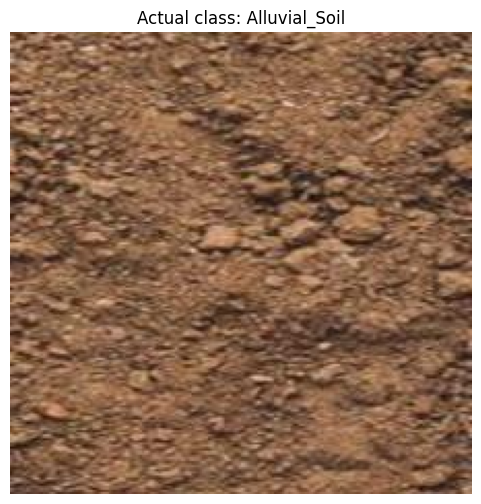

In [ ]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Actual class: {selected_class}")
plt.axis("off")
plt.show()

In [ ]:
# Get the layers after EfficientNetB0
gap_layer = model.get_layer("global_average_pooling2d")
dropout_layer = model.get_layer("dropout")
dense_layer = model.get_layer("dense")

gradcam_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer(gradcam_layer_name).output,
        dense_layer(
            dropout_layer(
                gap_layer(
                    base_model.get_layer(gradcam_layer_name).output
                ),
                training=False
            ),
            training=False
        )
    ]
)

print("Grad-CAM model created successfully.")

Grad-CAM model created successfully.


In [ ]:
print("Grad-CAM model input:", gradcam_model.input.shape)
print("Grad-CAM outputs:")
print("Feature maps:", gradcam_model.output[0].shape)
print("Class predictions:", gradcam_model.output[1].shape)

Grad-CAM model input: (None, 224, 224, 3)
Grad-CAM outputs:
Feature maps: (None, 7, 7, 1280)
Class predictions: (None, 7)


In [ ]:
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

print("Input shape:", img_array.shape)
print("Pixel range:", img_array.min(), "to", img_array.max())

Input shape: (1, 224, 224, 3)
Pixel range: 0.0 to 244.0


In [ ]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = gradcam_model(img_array)

    predicted_class = tf.argmax(predictions[0])
    class_score = predictions[:, predicted_class]

grads = tape.gradient(class_score, conv_outputs)

print("Predicted class index:", predicted_class.numpy())
print("Predicted class:", class_names[predicted_class.numpy()])
print("Prediction probabilities:", predictions.numpy())
print("Feature map shape:", conv_outputs.shape)
print("Gradient shape:", grads.shape)

Predicted class index: 3
Predicted class: Laterite_Soil
Prediction probabilities: [[0.22179632 0.0497319  0.12950298 0.4777622  0.00327792 0.03141034
  0.08651826]]
Feature map shape: (1, 7, 7, 1280)
Gradient shape: (1, 7, 7, 1280)


In [ ]:
# Remove the batch dimension
conv_outputs = conv_outputs[0]
grads = grads[0]

# Average gradients across spatial dimensions
pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

# Weight each feature map by its importance
heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

# Keep only positive contributions
heatmap = tf.maximum(heatmap, 0)

# Normalize to 0-1
max_value = tf.reduce_max(heatmap)

if max_value > 0:
    heatmap /= max_value

heatmap = heatmap.numpy()

print("Heatmap shape:", heatmap.shape)
print("Heatmap range:", heatmap.min(), "to", heatmap.max())

Heatmap shape: (7, 7)
Heatmap range: 0.0 to 1.0


In [ ]:
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (224, 224)
).numpy().squeeze()

print("Resized heatmap shape:", heatmap_resized.shape)

Resized heatmap shape: (224, 224)


## How Grad-CAM Works

Grad-CAM (Gradient-weighted Class Activation Mapping) provides a visual
explanation of a CNN prediction by identifying image regions that contribute
to the model's output for a selected class.

The procedure is:

1. Obtain convolutional feature maps from a late CNN layer.
2. Calculate the gradients of the selected class score with respect to those
   feature maps.
3. Average the gradients spatially to obtain importance weights.
4. Weight the feature maps using these importance values.
5. Combine the weighted feature maps and apply ReLU.
6. Normalize and resize the resulting activation map to the original image
   resolution.

The resulting heatmap highlights regions that had stronger influence on the
model's prediction.

Grad-CAM indicates model attention or contribution patterns; it does not
prove that the highlighted visual features are causal or scientifically
diagnostic of soil type.

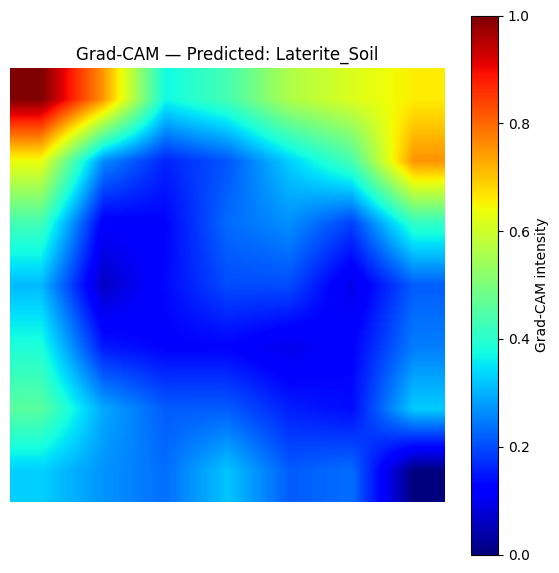

In [ ]:
plt.figure(figsize=(7, 7))

plt.imshow(heatmap_resized, cmap="jet")
plt.colorbar(label="Grad-CAM intensity")

plt.title(
    f"Grad-CAM — Predicted: {class_names[predicted_class.numpy()]}"
)

plt.axis("off")
plt.show()

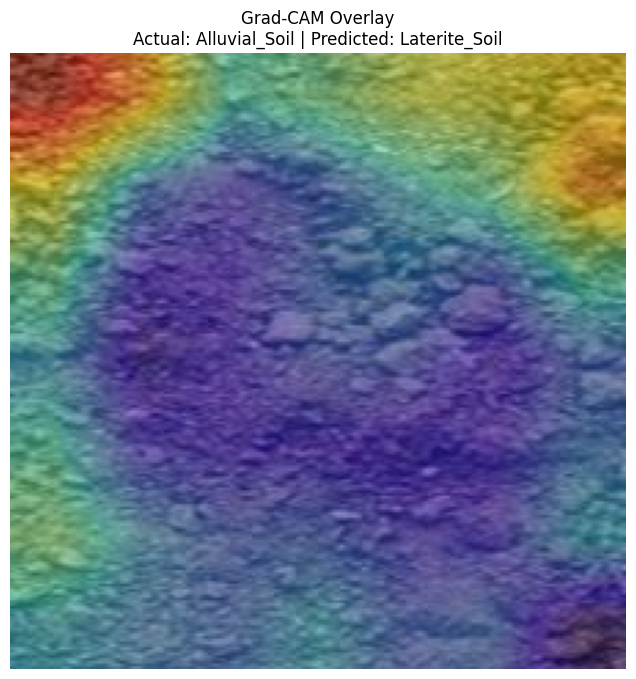

In [ ]:
import matplotlib.cm as cm

# Convert original image to numpy array
original_img = np.array(img).astype(np.uint8)

# Convert heatmap to RGB
heatmap_color = cm.jet(heatmap_resized)[..., :3]

# Convert to 0-255
heatmap_color = np.uint8(255 * heatmap_color)

# Blend original image and heatmap
alpha = 0.4

overlay = (
    original_img * (1 - alpha) +
    heatmap_color * alpha
).astype(np.uint8)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Actual: {selected_class} | "
    f"Predicted: {class_names[predicted_class.numpy()]}"
)
plt.axis("off")
plt.show()

## Incorrect Prediction Analysis

For the selected example, the actual class is `Alluvial_Soil`, while the
model predicts `Laterite_Soil`.

The Grad-CAM heatmap is used to inspect which image regions contributed most
strongly to this incorrect prediction.

The highlighted regions should be interpreted as areas that influenced the
CNN's prediction rather than as confirmed visual indicators of Laterite Soil.

This analysis helps identify possible sources of model confusion and provides
a qualitative way to inspect whether the model is focusing on relevant soil
regions or potentially irrelevant image characteristics.

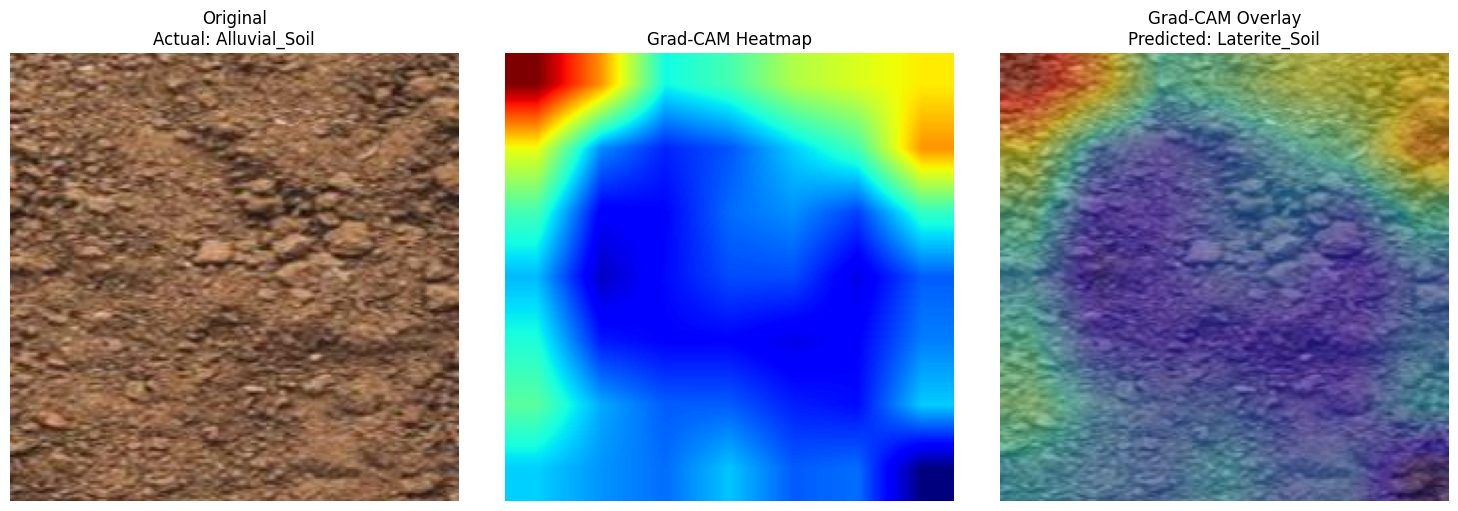

In [ ]:
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(f"Original\nActual: {selected_class}")
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Predicted: {class_names[predicted_class.numpy()]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
correct_example = None

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(TEST_DIR, class_name)

    for filename in os.listdir(class_dir):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):

            path = os.path.join(class_dir, filename)

            test_img = tf.keras.utils.load_img(
                path,
                target_size=(224, 224)
            )

            test_array = tf.keras.utils.img_to_array(test_img)
            test_array = np.expand_dims(test_array, axis=0)

            prediction = model.predict(test_array, verbose=0)
            predicted_index = np.argmax(prediction[0])

            if predicted_index == class_index:
                correct_example = (
                    path,
                    class_name,
                    predicted_index,
                    prediction[0][predicted_index]
                )
                break

    if correct_example is not None:
        break

print("Image:", correct_example[0])
print("Actual:", correct_example[1])
print("Predicted:", class_names[correct_example[2]])
print("Confidence:", correct_example[3])

Image: /content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split/test/Alluvial_Soil/2.jpg
Actual: Alluvial_Soil
Predicted: Alluvial_Soil
Confidence: 0.72998387


## Correct Prediction Analysis

For the selected correct example, the actual and predicted class are both
`Alluvial_Soil`.

The Grad-CAM visualization shows which image regions contributed to the
correct classification.

When the highlighted regions correspond to visible soil texture or surface
characteristics, this provides qualitative evidence that the model is using
visually relevant regions. However, Grad-CAM alone cannot establish which
specific physical soil properties the CNN has learned.

In [ ]:
correct_path = correct_example[0]

correct_img = tf.keras.utils.load_img(
    correct_path,
    target_size=(224, 224)
)

correct_array = tf.keras.utils.img_to_array(correct_img)
correct_array = np.expand_dims(correct_array, axis=0)

print("Correct image loaded.")
print("Shape:", correct_array.shape)

Correct image loaded.
Shape: (1, 224, 224, 3)


In [ ]:
with tf.GradientTape() as tape:
    correct_conv_outputs, correct_predictions = gradcam_model(correct_array)

    correct_predicted_class = tf.argmax(correct_predictions[0])
    correct_class_score = correct_predictions[:, correct_predicted_class]

correct_grads = tape.gradient(
    correct_class_score,
    correct_conv_outputs
)

print("Predicted class:", class_names[correct_predicted_class.numpy()])
print("Prediction probabilities:", correct_predictions.numpy())
print("Feature map shape:", correct_conv_outputs.shape)
print("Gradient shape:", correct_grads.shape)

Predicted class: Alluvial_Soil
Prediction probabilities: [[0.7299816  0.06197334 0.00279269 0.05607865 0.0031781  0.00449522
  0.14150035]]
Feature map shape: (1, 7, 7, 1280)
Gradient shape: (1, 7, 7, 1280)


In [ ]:
correct_conv_outputs = correct_conv_outputs[0]
correct_grads = correct_grads[0]

correct_pooled_grads = tf.reduce_mean(
    correct_grads,
    axis=(0, 1)
)

correct_heatmap = tf.reduce_sum(
    correct_conv_outputs * correct_pooled_grads,
    axis=-1
)

correct_heatmap = tf.maximum(correct_heatmap, 0)

correct_max_value = tf.reduce_max(correct_heatmap)

if correct_max_value > 0:
    correct_heatmap /= correct_max_value

correct_heatmap = correct_heatmap.numpy()

correct_heatmap_resized = tf.image.resize(
    correct_heatmap[..., np.newaxis],
    (224, 224)
).numpy().squeeze()

print("Heatmap shape:", correct_heatmap.shape)
print("Resized heatmap shape:", correct_heatmap_resized.shape)

Heatmap shape: (7, 7)
Resized heatmap shape: (224, 224)


In [ ]:
correct_original = np.array(correct_img).astype(np.uint8)

correct_heatmap_color = cm.jet(
    correct_heatmap_resized
)[..., :3]

correct_heatmap_color = np.uint8(
    255 * correct_heatmap_color
)

correct_overlay = (
    correct_original * 0.6 +
    correct_heatmap_color * 0.4
).astype(np.uint8)

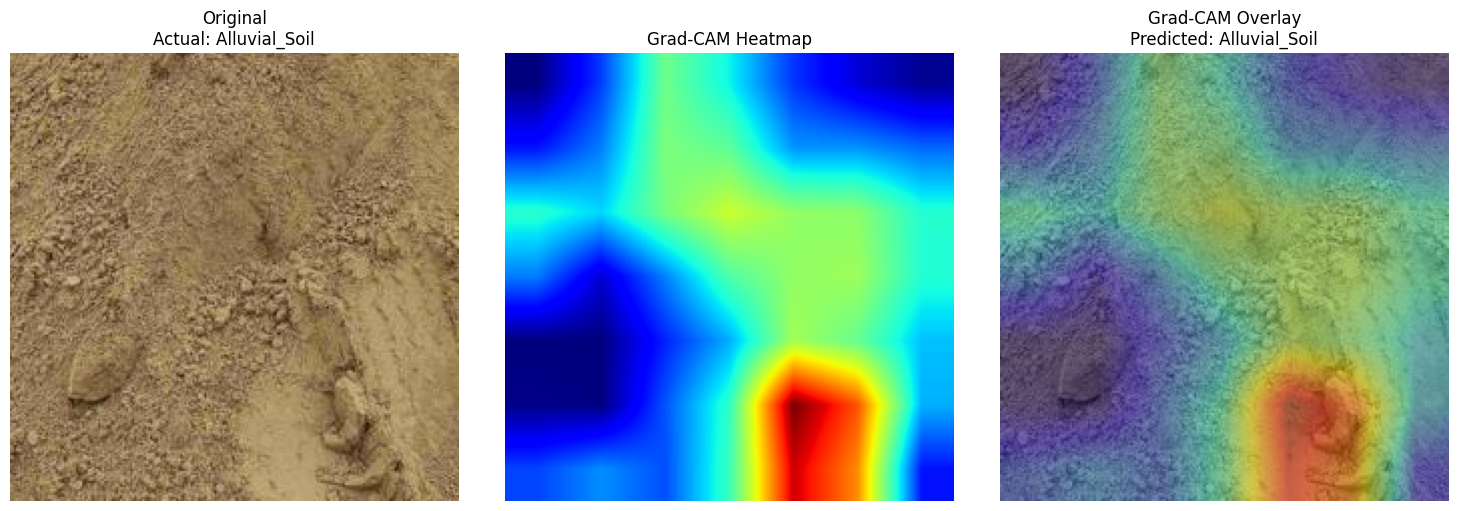

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(correct_original)
plt.title("Original\nActual: Alluvial_Soil")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(correct_heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(correct_overlay)
plt.title(
    "Grad-CAM Overlay\n"
    "Predicted: Alluvial_Soil"
)
plt.axis("off")

plt.tight_layout()
plt.show()

## Grad-CAM Analysis Summary

Grad-CAM was applied to the fine-tuned EfficientNetB0 soil classification
model to visualize image regions contributing to its predictions.

Two examples were analyzed:

1. Correct prediction:
   - Actual class: Alluvial_Soil
   - Predicted class: Alluvial_Soil
   - Confidence: approximately 73.0%

2. Incorrect prediction:
   - Actual class: Alluvial_Soil
   - Predicted class: Laterite_Soil
   - Confidence: approximately 47.8%

The correctly classified example showed stronger activation over regions
containing visible soil texture and surface characteristics. The
incorrect example was analyzed to investigate the spatial regions
associated with the incorrect Laterite_Soil prediction.

Grad-CAM provides an interpretation of model attention and can help
identify potentially relevant or misleading image regions. However,
Grad-CAM does not establish causality or prove that a particular visual
feature is responsible for the classification.

### Interpretation Limitation

Grad-CAM is an interpretability technique rather than a validation method.
Highlighted regions indicate where the trained CNN had stronger class-related
activation, but they do not establish causal relationships or guarantee that
the model is using scientifically meaningful soil properties.

The correct and incorrect examples are therefore used for qualitative model
inspection rather than quantitative proof of model reasoning.